In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv')
print(df.shape)
print(df.head())
print(df.isnull().sum())
print(df['target'].value_counts())

(1025, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
target
1    526
0    499
Name: count, dtype: int64


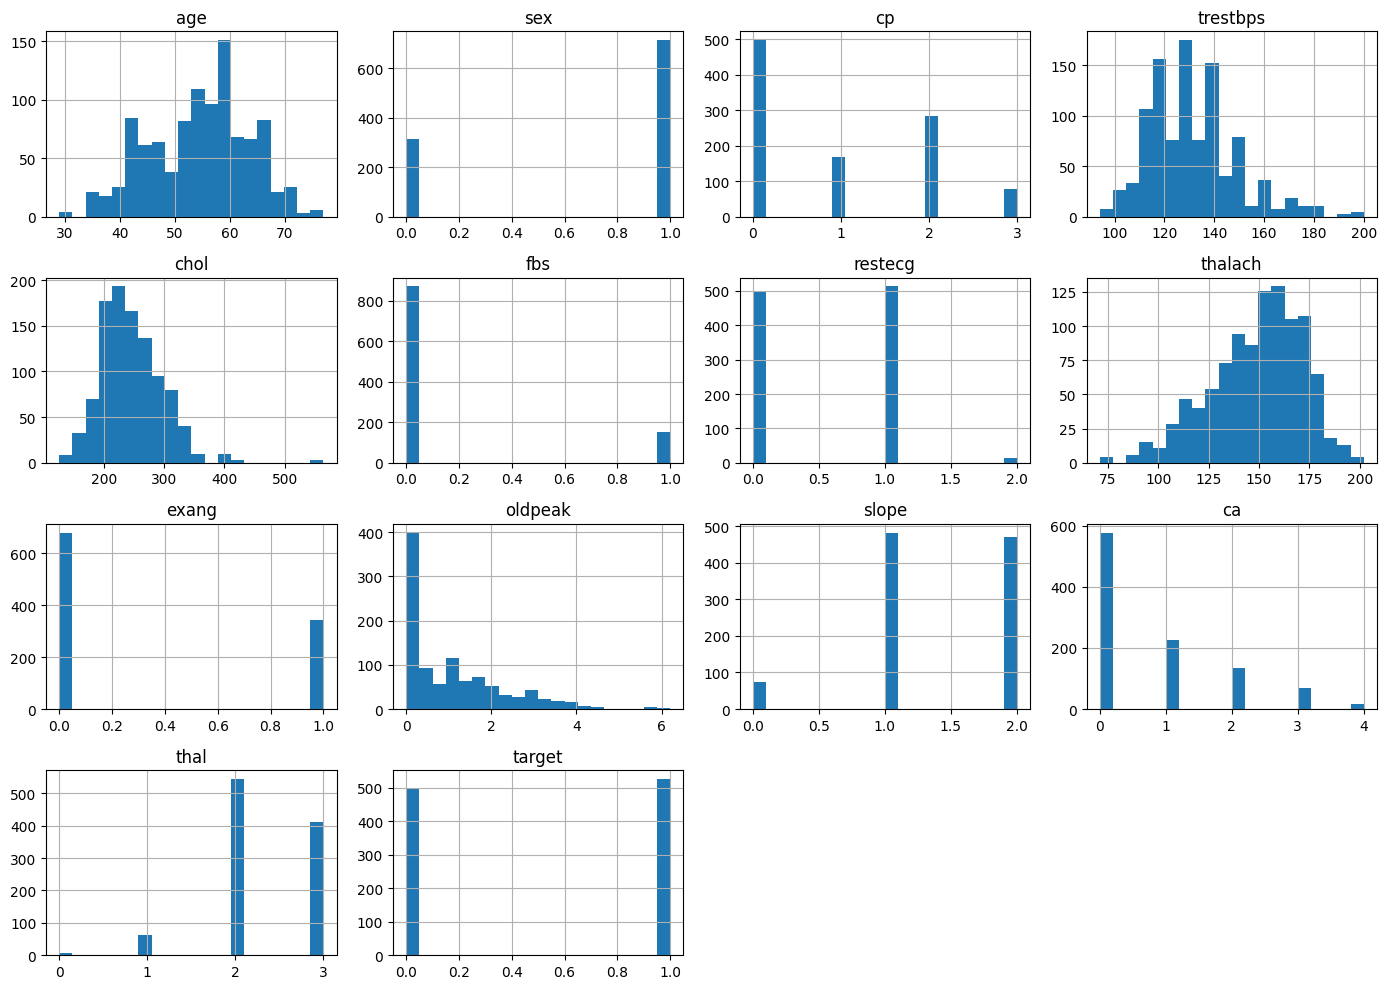

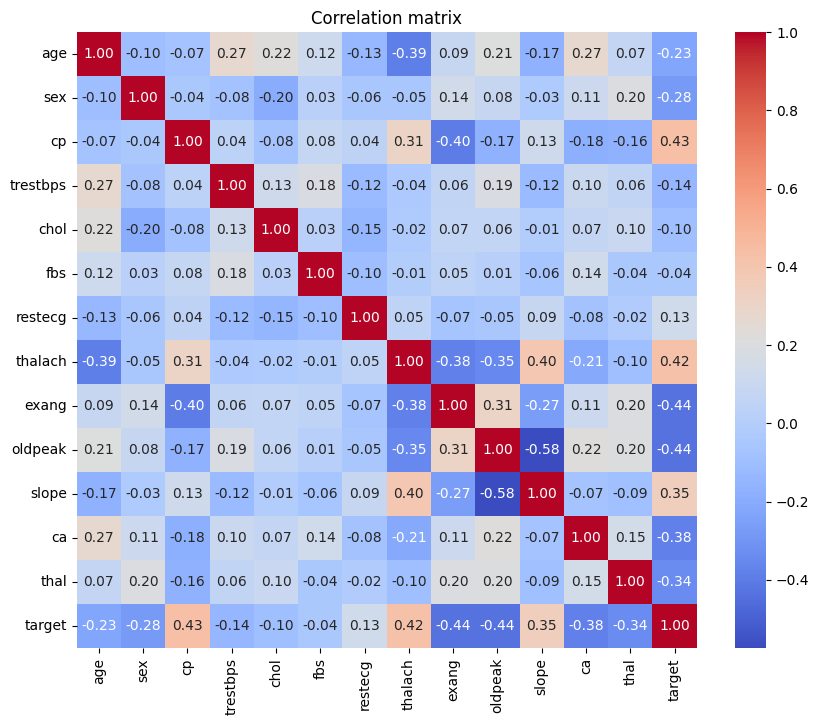

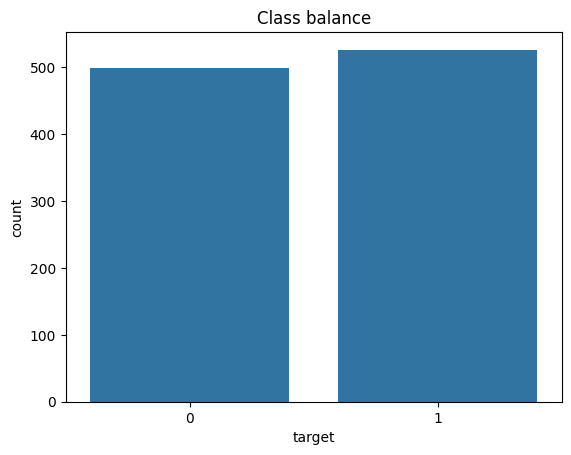

In [2]:
df.hist(bins=20, figsize=(14,10))
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()

sns.countplot(x='target', data=df)
plt.title('Class balance')
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000), True),
    'Random Forest':       (RandomForestClassifier(n_estimators=100, random_state=42), False),
    'SVM':                 (SVC(kernel='rbf', probability=True), True),
    'XGBoost':             (XGBClassifier(n_estimators=100, learning_rate=0.1,
                             eval_metric='logloss', verbosity=0), False),
}

print(f"{'Model':<22} {'Accuracy':>9} {'F1':>8} {'ROC-AUC':>9}")
print("-" * 52)
for name, (model, scaled) in models.items():
    Xtr = X_train_sc if scaled else X_train
    Xte = X_test_sc  if scaled else X_test
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    proba = model.predict_proba(Xte)[:,1]
    print(f"{name:<22} {accuracy_score(y_test,preds):>9.3f} "
          f"{f1_score(y_test,preds):>8.3f} "
          f"{roc_auc_score(y_test,proba):>9.3f}")

Model                   Accuracy       F1   ROC-AUC
----------------------------------------------------
Logistic Regression        0.795    0.811     0.879
Random Forest              0.985    0.985     1.000
SVM                        0.888    0.894     0.963
XGBoost                    0.985    0.985     0.988


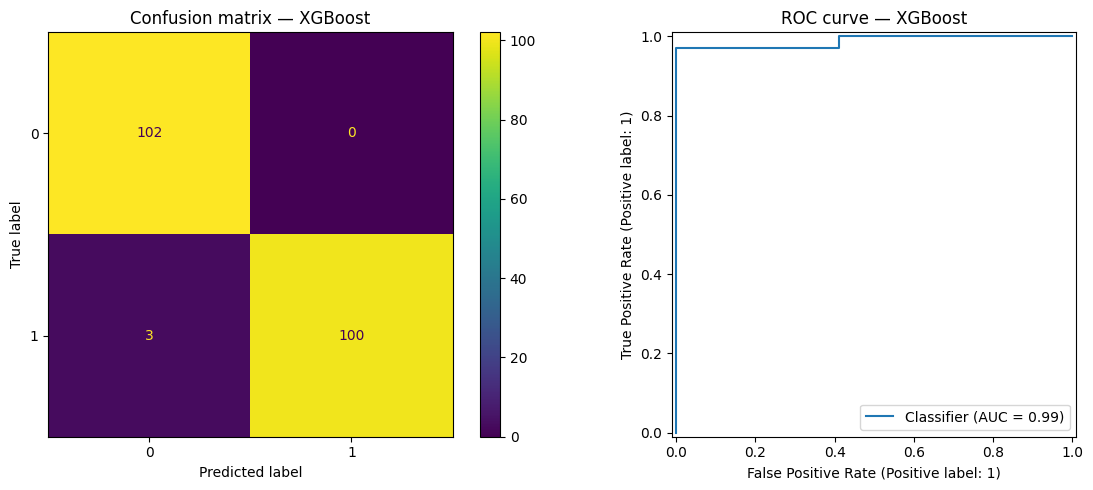

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

best_model = XGBClassifier(n_estimators=100, learning_rate=0.1,
                           eval_metric='logloss', verbosity=0)
best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)
proba = best_model.predict_proba(X_test)[:,1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, preds, ax=axes[0])
axes[0].set_title('Confusion matrix — XGBoost')

RocCurveDisplay.from_predictions(y_test, proba, ax=axes[1])
axes[1].set_title('ROC curve — XGBoost')

plt.tight_layout()
plt.show()

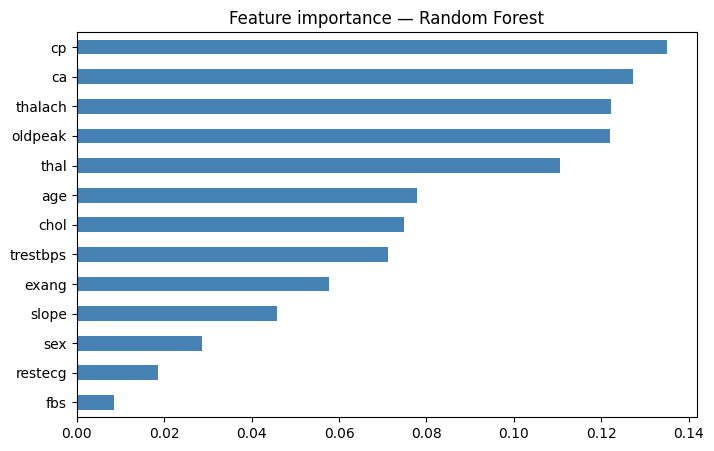

In [6]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8,5), color='steelblue')
plt.title('Feature importance — Random Forest')
plt.show()